<a href="https://colab.research.google.com/github/priya10241/Virality/blob/main/Virality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<h2> Load Dataset </h2>

In [3]:
df_train = pd.read_csv("Train.csv")

In [4]:
df_test = pd.read_csv("test_reddit.csv")

In [5]:
df_train.head()

,Post ID,Subreddit,Post Title,Upvotes,Downvotes,Score,Upvote Ratio,Author,Post Time,Number of Comments,...,First Hour Upvotes,viral,title_length,title_sentiment,hour,day,weekday,month,year,category_encoded
0,1h7hvjd,memes,It’s a full time job,1,0,1,1.00,onegonethusband,2024-12-05 19:44:21,0,...,1.0,0,20,0.35,19,5,3,12,2024,3
1,1h7hqx1,memes,Maybe we do need the Bible in schools lol,4,0,4,1.00,DrizzleDrain,2024-12-05 19:38:53,1,...,4.0,0,41,0.80,19,5,3,12,2024,3
2,1h7hpdm,memes,Sad Guts,0,0,0,0.50,urzaga,2024-12-05 19:37:07,0,...,0.0,0,8,-0.50,19,5,3,12,2024,3
3,1h7hksk,memes,Sad Hulk,6,0,6,0.88,Clear-Example3029,2024-12-05 19:31:51,1,...,6.0,0,8,-0.50,19,5,3,12,2024,3
4,1h7hiw6,memes,"Hey, neck-bearded fedora-wearers. These memes ...",2,0,2,0.63,AverageSign,2024-12-05 19:29:40,1,...,2.0,0,93,0.00,19,5,3,12,2024,3


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27587 entries, 0 to 27586
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Post ID                27587 non-null  object 
 1   Subreddit              27587 non-null  object 
 2   Post Title             27587 non-null  object 
 3   Upvotes                27587 non-null  int64  
 4   Downvotes              27587 non-null  int64  
 5   Score                  27587 non-null  int64  
 6   Upvote Ratio           27587 non-null  float64
 7   Author                 27587 non-null  object 
 8   Post Time              27587 non-null  object 
 9   Number of Comments     27587 non-null  int64  
 10  Crossposts Count       27587 non-null  int64  
 11  Permalink              27587 non-null  object 
 12  Image URL              27587 non-null  object 
 13  Image Format           27587 non-null  object 
 14  Image Dimensions       27587 non-null  object 
 15  Fi

In [7]:
df_test.head()

,Post ID,Subreddit,Post Title,Upvotes,Downvotes,Score,Upvote Ratio,Author,Post Time,Number of Comments,...,viral,title_length,title_sentiment,hour,day,weekday,month,year,img,category_encoded
0,1h5zql8,memes,What was his name…,544,0,544,0.97,BrockBracken,2024-12-03 22:10:47,78,...,0,18,0.0,22,3,1,12,2024,memes-1h5zql8.jpeg,3
1,1gpkzkr,comedyheaven,Cowboy,13212,0,13212,0.97,themastpraani,2024-11-12 13:42:22,64,...,1,6,0.0,13,12,1,11,2024,comedyheaven-1gpkzkr.jpeg,3
2,1fzow6b,worldpolitics,Random bug post #3: devil's coach-horse beetle...,26,0,26,0.91,DasAntwortviech,2024-10-09 11:12:14,2,...,0,74,-0.5,11,9,2,10,2024,worldpolitics-1fzow6b.jpeg,4
3,1h13469,MakeupAddiction,Ice queen FOTD,149,0,149,0.93,gabbyandarthur,2024-11-27 12:26:15,10,...,0,15,0.0,12,27,2,11,2024,MakeupAddiction-1h13469.jpeg,0
4,1h2h5or,FellowKids,Hello fellow meme enthusiasts,120,0,120,0.94,torontogrady,2024-11-29 08:18:10,10,...,0,29,0.0,8,29,4,11,2024,FellowKids-1h2h5or.jpeg,3


<h2> Feature importance and training model </h2>

In [8]:
from sklearn.ensemble import RandomForestClassifier


In [9]:
features = [
    'Subreddit Subscribers',
    'title_length',
    'title_sentiment',
    'hour',
    'weekday',
    'month',
    'category_encoded'
]

X = df_train[features]
y = df_train['viral']

In [10]:
critic_model = RandomForestClassifier(n_estimators=100, random_state=42)
critic_model.fit(X, y)

RandomForestClassifier(random_state=42)

--- Virality Feature Importance ---
                 Feature  Importance
1           title_length    0.279615
3                   hour    0.205606
0  Subreddit Subscribers    0.154934
2        title_sentiment    0.118909
4                weekday    0.112907
5                  month    0.065603
6       category_encoded    0.062426


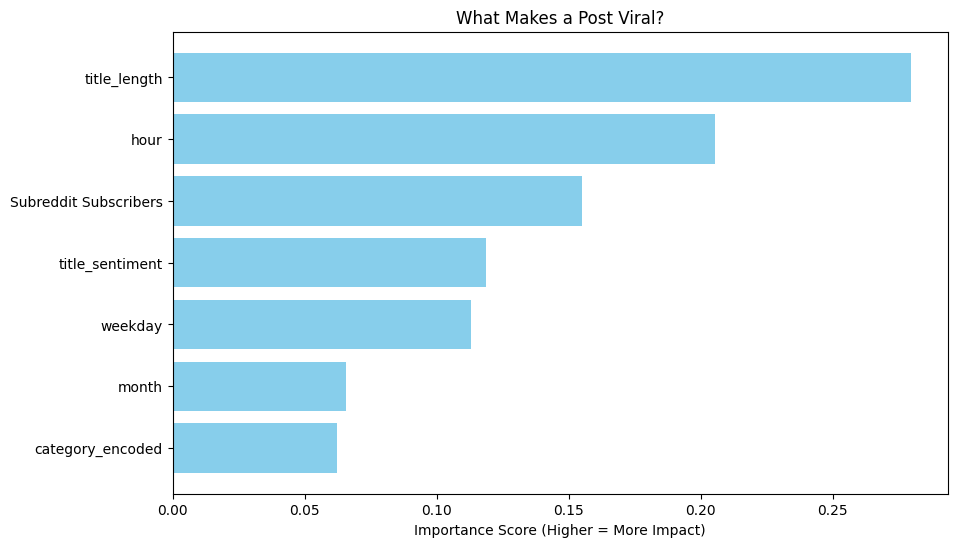

In [11]:
importances = critic_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- Virality Feature Importance ---")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score (Higher = More Impact)')
plt.title('What Makes a Post Viral?')
plt.gca().invert_yaxis() # Put the most important at the top
plt.show()

--- FINAL TEST RESULTS ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3613
           1       1.00      0.93      0.96       525

    accuracy                           0.99      4138
   macro avg       0.99      0.97      0.98      4138
weighted avg       0.99      0.99      0.99      4138



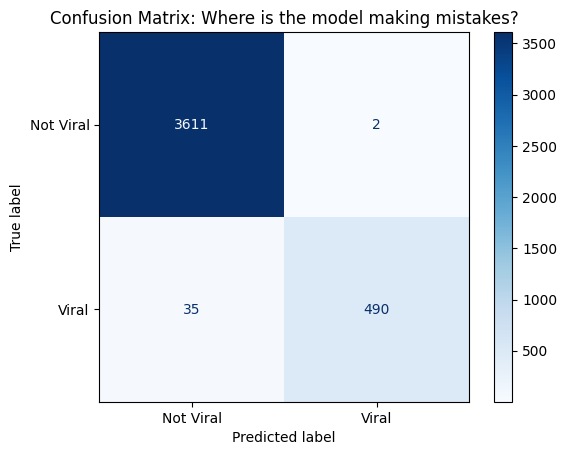

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

features = ['Subreddit Subscribers', 'title_length', 'title_sentiment', 'hour', 'weekday', 'month', 'category_encoded']
X_test = df_test[features]
y_test = df_test['viral']

y_pred_test = critic_model.predict(X_test)

print("--- FINAL TEST RESULTS ---")
print(classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Viral', 'Viral'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Where is the model making mistakes?')
plt.show()

In [13]:
import pickle

filename = 'virality_scorer_model.pkl'

with open(filename, 'wb') as file:
    pickle.dump(critic_model, file)
